In [1]:
# Import necessary modules

import matplotlib.pyplot as plt 
import numpy as np 

from landlab import HexModelGrid, RasterModelGrid 
from landlab.components import FastscapeEroder, FlowAccumulator, NormalFault 
from landlab.plot import imshow_grid 

%matplotlib inline

In [2]:
# Parameters to change

K = 0.0005 # stream power coefficient, bigger = streams erode more quickly  
U = 0.001 # uplift rate in meters per year 
dt = 1000 # time step in years 
dx = 10 # space step in meters 
nr = 60 # number of model rows 
nc = 100 # number of model columns

In [10]:
# Initiate the grid 

grid = HexModelGrid((nr, nc), 10, node_layout="rect") 

# Add a topographic__elevation field with noise 
z = grid.add_zeros("topographic__elevation", at="node") 
z[grid.core_nodes] += 100.0 + np.random.randn(grid.core_nodes.size) 
fr = FlowAccumulator(grid) 
fs = FastscapeEroder(grid, K_sp=K)  
nf = NormalFault( grid, fault_trace={"x1": 0, "x2": 800, "y1": 0, "y2": 500}, include_boundaries=True ) 

# Run this model for 20 1000-year timesteps (20_000 years). 

for i in range(20):
    fr.run_one_step() 
    fs.run_one_step(dt) 
    z[grid.core_nodes] += U * dt 

# Earthquake with 50 m displacement 
#nf.run_one_earthquake(dz=50) 

# Run this model again for 20 1000-year timesteps (20_000 years). 
#for i in range(20):
    #fr.run_one_step()
    #fs.run_one_step(dt)
    #z[grid.core_nodes] += U* dt

out=None

/opt/tljh/user/envs/ivy/lib/python3.13/site-packages/landlab/graph/sort/sort.py:724: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


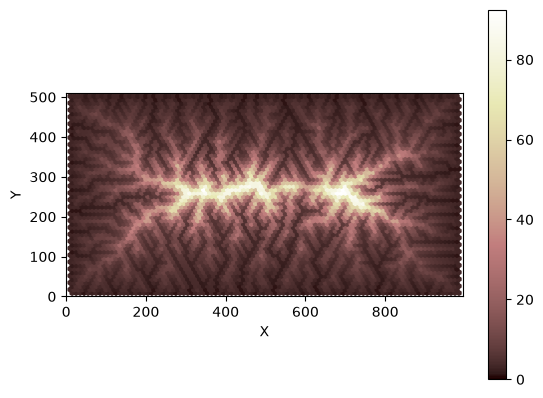

In [11]:
# plot the final topography 
imshow_grid(grid, z) 